# Camera undistortion (FOR BEV)

- For the MIT Han Lab BEVFusion codebase, the camera view transform is written as if the camera follows a pinhole projection with a 3×3 intrinsic matrix. Raw fisheye-distorted ZOD images are not what this implementation is set up for.
- The intrinsics passed into BEVFusion should be the intrinsics of that rectified image.
- after you undistort the raw fisheye image, the old raw-camera intrinsic matrix K is no longer the correct projection matrix for the new image.
- we want: (raw image,K,D)→undistort→(rectified image,new_K)→BEVFusion


- original ZOD front image: 3848 × 2168
- resized training image: 1248 × 704
SO WE NEED: Kraw --> undistort --> Krectified --> resize --> Kfinal. (focal length and principal point change with image resolution so must rescale) ---> feed Kfinal to BEV. 

In [24]:
# Imports + load parquet row + pick one frame/image

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
#for undistortion
import cv2

# ZOD SDK
from zod.data_classes.info import Information
from zod.data_classes.frame import ZodFrame
from zod.constants import Camera

# set seed
np.random.seed(42)

# Parquet index (note: file is ZODmoe..., not ODmoe...)
INDEX_PATH = Path("/home/edgelab/multimodal-MoE/outputs/index/ZODmoe_frames_with_xyxy_bboxes_and_solar_bins.parquet")
df = pd.read_parquet(INDEX_PATH)

print("Rows:", len(df))
print("Columns:", df.columns.tolist())

# Pick a row with pedestrians if available, else first row.
if "ped_present" in df.columns and (df["ped_present"] == 1).any():
    row = df[df["ped_present"] == 1].iloc[5000]
else:
    row = df.iloc[0]

frame_id = str(row["frame_id"])
image_path = Path(row["image_path"])  # original non-resized path from parquet
frame_dir = image_path.parent.parent   # .../<frame_id>/camera_front_dnat/<img>.jpg -> .../<frame_id>

print("Selected frame_id:", frame_id)
print("Original image path:", image_path)
print("Frame dir:", frame_dir)

Rows: 99999
Columns: ['frame_id', 'time', 'image_path', 'resized_image_path', 'orig_w', 'orig_h', 'new_w', 'new_h', 'sx', 'sy', 'scraped_weather', 'time_of_day', 'solar_angle_elevation', 'country_code', 'road_type', 'road_condition', 'ped_count_clear', 'ped_count_unclear', 'ped_occ_none', 'ped_occ_light', 'ped_occ_medium', 'ped_occ_heavy', 'ped_occ_veryheavy', 'ped_occ_missing', 'ped_occ_unknown', 'ped_uuid', 'ped_unclear_list', 'ped_occlusion_list', 'ped_points_xy_resized', 'ped_bin_4', 'ped_present', 'xyxy_bboxes', 'solar_context_bin']
Selected frame_id: 060350
Original image path: /home/edgelab/zod_dino_data/train2017/060350/camera_front_dnat/060350_india_2020-11-16T11:40:58.224750Z.jpg
Frame dir: /home/edgelab/zod_dino_data/train2017/060350


In [25]:
# Build zod_frame from raw folder

def make_zodframe_from_raw(frame_dir: Path) -> ZodFrame:
    """
    Build ZodFrame from raw single-frame directory layout.
    This fixes relative paths in info.json to be frame-local.
    """
    info_dict = json.loads((frame_dir / "info.json").read_text())
    fid = info_dict.get("id", frame_dir.name)
    prefix = f"single_frames/{fid}/"

    def fix_path(p):
        if p is None:
            return None
        if p.startswith(prefix):
            return p[len(prefix):]
        if p.startswith("single_frames/"):
            return p.split("/", 2)[-1]
        return p

    # top-level paths
    for k in ["calibration_path", "ego_motion_path", "metadata_path", "oxts_path", "vehicle_data_path"]:
        if info_dict.get(k) is not None:
            info_dict[k] = fix_path(info_dict[k])

    # annotation paths
    for ann in info_dict.get("annotations", {}).values():
        if ann.get("filepath") is not None:
            ann["filepath"] = fix_path(ann["filepath"])

    # camera frame paths
    for arr in info_dict.get("camera_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    # lidar frame paths
    for arr in info_dict.get("lidar_frames", {}).values():
        for x in arr:
            if x.get("filepath") is not None:
                x["filepath"] = fix_path(x["filepath"])

    info = Information.from_dict(info_dict)
    info.convert_paths_to_absolute(str(frame_dir))
    return ZodFrame(info)

zod_frame = make_zodframe_from_raw(frame_dir)
calib = zod_frame.calibration

print("zod_frame id:", zod_frame.info.id)
print("Camera intrinsics shape:", calib.cameras[Camera.FRONT].intrinsics.shape)
print("Camera distortion:", calib.cameras[Camera.FRONT].distortion)
print("K:" , calib.cameras[Camera.FRONT].intrinsics)

zod_frame id: 060350
Camera intrinsics shape: (3, 4)
Camera distortion: [-0.00592982 -0.05365763  0.06591502 -0.02476903]
K: [[1.85734965e+03 0.00000000e+00 1.91792462e+03 0.00000000e+00]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00 0.00000000e+00]]


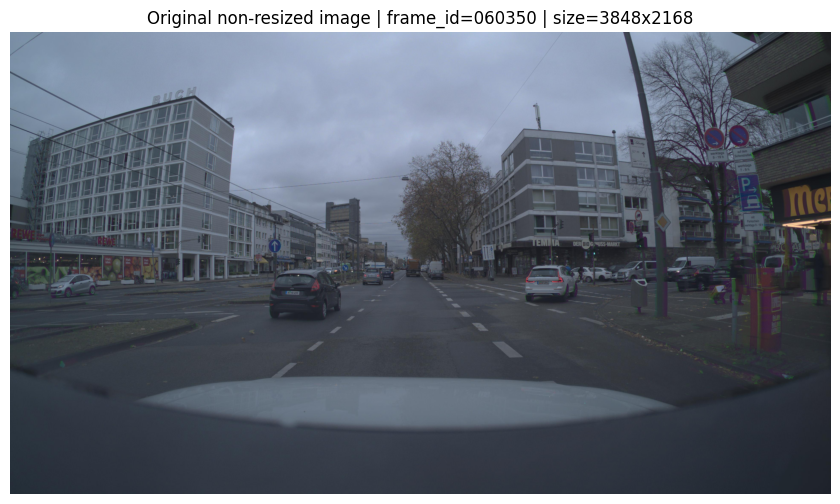

In [26]:
# Load and display ORIGINAL (non-resized) image from parquet path

img_rgb = np.array(Image.open(image_path).convert("RGB"))
h, w = img_rgb.shape[:2]

plt.figure(figsize=(12, 6))
plt.imshow(img_rgb)
plt.title(f"Original non-resized image | frame_id={frame_id} | size={w}x{h}")
plt.axis("off")
plt.show()

https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html (cv2 undistortion using intrinsics matrix and distortion coefficients or undistortion coefficients)

intrinsics K: [[1.85734965e+03 0.00000000e+00 1.91792462e+03]
 [0.00000000e+00 1.85734965e+03 1.11514928e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion D: [[-0.00592982]
 [-0.05365763]
 [ 0.06591502]
 [-0.02476903]]
new_K: [[1.63296874e+03 0.00000000e+00 1.90918907e+03]
 [0.00000000e+00 1.63296874e+03 1.12765936e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


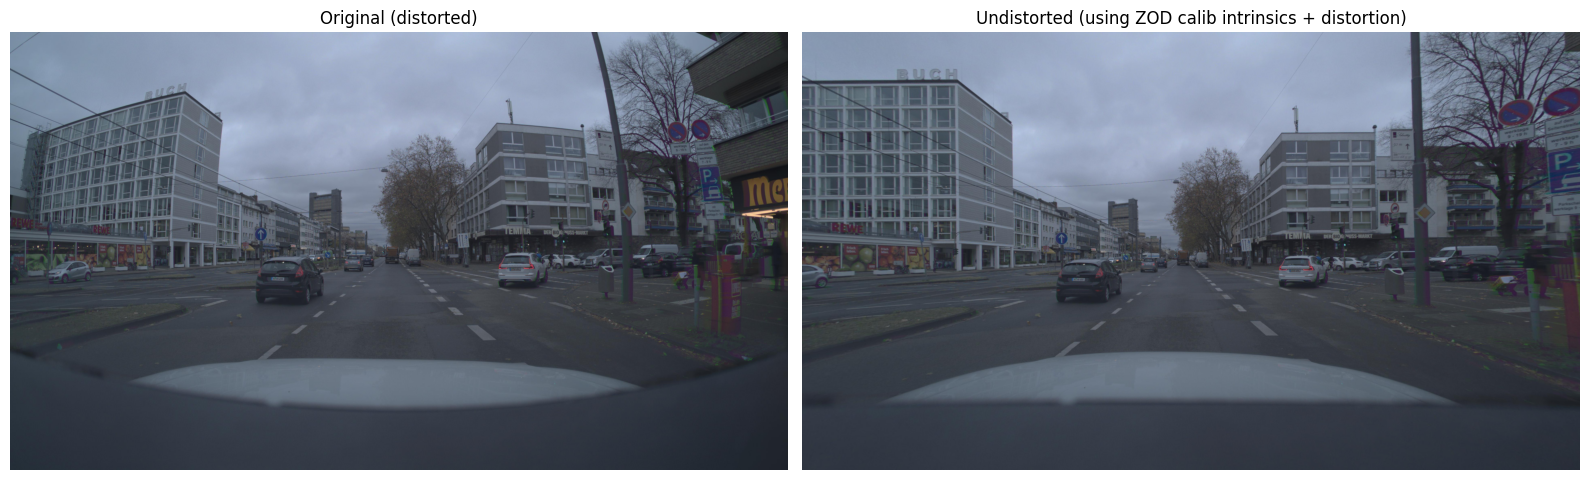

In [27]:
# Undistort using ZOD calibration intrinsics + distortion (Kannala/fisheye style via OpenCV)

cam_calib = calib.cameras[Camera.FRONT]

# ZOD intrinsics are stored as 3x4; OpenCV fisheye expects 3x3.
K = cam_calib.intrinsics[:3, :3].astype(np.float64)
print(f"intrinsics K: {K}")
# D is a 4x1 vector (distortion coefficients)
D = cam_calib.distortion.astype(np.float64).reshape(4, 1)
print(f"distortion D: {D}")

# Build undistortion mapping.
# balance=0.0 => less black border (more crop), balance=1.0 => keep more FoV
balance = 0.0
new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
    K, D, (w, h), np.eye(3), balance=balance
)
print("new_K:" , new_K)
map1, map2 = cv2.fisheye.initUndistortRectifyMap(
    K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2
)

# Remap image (we remap the pixels to the undistorted image)
# for each pixel: "where should I sample from in the original distorted image?” That produces a rectified image consistent with new_K."
undistorted_rgb = cv2.remap(
    img_rgb, map1, map2, interpolation=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
)

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original (distorted)")
axes[0].axis("off")

axes[1].imshow(undistorted_rgb)
axes[1].set_title("Undistorted (using ZOD calib intrinsics + distortion)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# Sanity check: project pedestrian 3D boxes onto the
# undistorted + resized image using:
#
#   ZOD SDK transforms  -> camera frame
#   BEV_intrinsics      -> pixel coordinates
#
# This verifies that the final camera geometry is consistent.
# ============================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

from zod.constants import Camera
from zod.utils.geometry import transform_points

# ------------------------------------------------------------
# Helper: build cuboid corners from center, dimensions, quaternion
# ------------------------------------------------------------
def make_box_corners_3d(center_xyz, size_lwh, orientation):
    """
    Build the 8 corners of a 3D box in the SAME source frame
    as the provided center.

    Parameters
    ----------
    center_xyz : array-like of shape (3,)
        Box center [x, y, z]
    size_lwh : array-like of shape (3,)
        Box size [length, width, height]
    orientation : Quaternion
        Full 3D box orientation as a quaternion.
        Expected to expose `.rotation_matrix` of shape (3, 3).

    Returns
    -------
    corners : np.ndarray of shape (8, 3)
        8 corners of the cuboid in the same frame as center_xyz
    """
    center_xyz = np.asarray(center_xyz, dtype=np.float64)
    size_lwh = np.asarray(size_lwh, dtype=np.float64)

    cx, cy, cz = center_xyz
    l, w, h = size_lwh

    # Local box corners around the origin before rotation.
    # Convention:
    #   length along local x
    #   width  along local y
    #   height along local z
    x_c = np.array([ l/2,  l/2, -l/2, -l/2,  l/2,  l/2, -l/2, -l/2], dtype=np.float64)
    y_c = np.array([ w/2, -w/2, -w/2,  w/2,  w/2, -w/2, -w/2,  w/2], dtype=np.float64)
    z_c = np.array([ h/2,  h/2,  h/2,  h/2, -h/2, -h/2, -h/2, -h/2], dtype=np.float64)

    corners_local = np.stack([x_c, y_c, z_c], axis=1)  # (8, 3)

    # Full 3D rotation from quaternion
    R = np.asarray(orientation.rotation_matrix, dtype=np.float64)  # (3, 3)

    # Rotate then translate into the source frame
    corners_rot = corners_local @ R.T
    corners = corners_rot + np.array([cx, cy, cz], dtype=np.float64)

    return corners


# ------------------------------------------------------------
# Helper: project camera-frame 3D points using final intrinsics
# ------------------------------------------------------------
def project_points_camera_frame_to_pixels(points_cam, K):
    """
    Project 3D points already expressed in CAMERA FRAME
    into image pixels using standard pinhole projection.

    Parameters
    ----------
    points_cam : np.ndarray of shape (N, 3)
        3D points in camera frame
    K : np.ndarray of shape (3, 3)
        Final intrinsics for the undistorted + resized image

    Returns
    -------
    pixels : np.ndarray of shape (N, 2)
        Pixel coordinates
    valid_mask : np.ndarray of shape (N,)
        True for points with positive depth
    """
    x = points_cam[:, 0]
    y = points_cam[:, 1]
    z = points_cam[:, 2]

    valid_mask = z > 1e-6

    u = np.full_like(z, fill_value=np.nan, dtype=np.float64)
    v = np.full_like(z, fill_value=np.nan, dtype=np.float64)

    u[valid_mask] = K[0, 0] * (x[valid_mask] / z[valid_mask]) + K[0, 2]
    v[valid_mask] = K[1, 1] * (y[valid_mask] / z[valid_mask]) + K[1, 2]

    pixels = np.stack([u, v], axis=1)
    return pixels, valid_mask


# ------------------------------------------------------------
# Helper: draw projected cuboid
# ------------------------------------------------------------
def draw_projected_cuboid(image_rgb, pixels, valid_mask, color=(0, 255, 0), thickness=2):
    """
    Draw a 3D cuboid projected into 2D.
    Assumes pixel ordering matches make_box_corners_3d().
    """
    img = image_rgb.copy()

    # If any corner is behind the camera, skip for safety
    if not np.all(valid_mask):
        return img

    pts = np.round(pixels).astype(int)

    # Top face: indices 0,1,2,3
    # Bottom face: indices 4,5,6,7
    top_edges = [(0,1), (1,2), (2,3), (3,0)]
    bottom_edges = [(4,5), (5,6), (6,7), (7,4)]
    side_edges = [(0,4), (1,5), (2,6), (3,7)]

    for i, j in top_edges + bottom_edges + side_edges:
        p1 = tuple(pts[i])
        p2 = tuple(pts[j])
        cv2.line(img, p1, p2, color=color, thickness=thickness)

    return img


# ------------------------------------------------------------
# Helper: draw projected center point
# ------------------------------------------------------------
def draw_projected_center(image_rgb, pixel_xy, color=(255, 0, 0), radius=5):
    img = image_rgb.copy()
    if np.all(np.isfinite(pixel_xy)):
        u, v = np.round(pixel_xy).astype(int)
        h, w = img.shape[:2]
        if 0 <= u < w and 0 <= v < h:
            cv2.circle(img, (u, v), radius, color, -1)
    return img

Found 9 pedestrian(s) with 3D annotation in this frame.
T_cam_from_lidar:
[[ 0.99975967  0.00483183  0.02138334  0.03784955]
 [ 0.02139159 -0.00166327 -0.99976979 -0.57745838]
 [-0.00479515  0.99998694 -0.00176623 -0.95567663]
 [ 0.          0.          0.          1.        ]]

Pedestrian 1/9
uuid: 18f1d258-1450-4cd1-8e10-743f14822a68
center_lidar: [ 8.72960687 54.30617889 -0.81362041]
size_lwh: [0.41666667 0.65833333 1.45512667]
orientation quaternion: 0.860 -0.021i -0.033j +0.508k

Pedestrian 2/9
uuid: 2b1e9240-5cf6-416c-91f6-17c5f16eeb84
center_lidar: [11.61263915  7.71075488 -0.48026065]
size_lwh: [0.48810658 0.63124348 1.81617556]
orientation quaternion: 0.966 -0.020i -0.052j +0.253k

Pedestrian 3/9
uuid: 356cd64a-ff5d-490a-ba09-1e838c95a5b0
center_lidar: [10.16429972 10.72036894 -0.67674185]
size_lwh: [0.63400876 0.60674157 1.66008852]
orientation quaternion: -0.601 -0.025i +0.034j +0.798k

Pedestrian 4/9
uuid: 366dab83-ab60-4cbf-8e95-b790cd6e335a
center_lidar: [-36.71974806  45

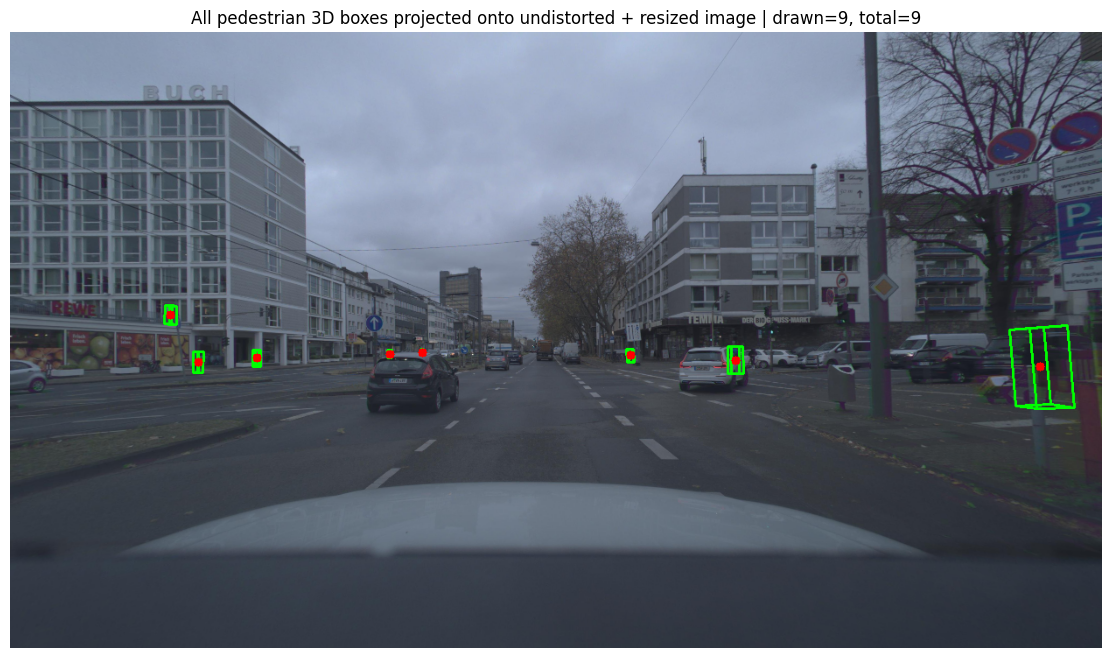

In [49]:
# ============================================================
# Project ALL pedestrian 3D boxes in this keyframe
# CASE: 3D boxes are in LiDAR frame and orientation is quaternion
# ============================================================

# Assumptions:
# - `zod_frame` is your loaded ZOD frame object
# - `calib` is the frame calibration object
# - `resized_undistorted_img` is the final image
# - `BEV_intrinsics` is the final 3x3 matrix computed above
# - `make_box_corners_3d`, `project_points_camera_frame_to_pixels`,
#   `draw_projected_cuboid`, and `draw_projected_center`
#   have already been defined
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from zod.constants import Camera, Lidar, AnnotationProject
from zod.utils.geometry import transform_points

img_vis = resized_undistorted_img.copy()

# ------------------------------------------------------------
# 1) Get all pedestrian annotations with 3D boxes
# ------------------------------------------------------------
anns = zod_frame.get_annotation(AnnotationProject.OBJECT_DETECTION)

pedestrian_objs = []
for obj in anns:
    # Keep only pedestrians that have 3D geometry
    if obj.name == "Pedestrian" and obj.box3d is not None:
        pedestrian_objs.append(obj)

if len(pedestrian_objs) == 0:
    raise ValueError("No pedestrian with 3D annotation found in this frame.")

print(f"Found {len(pedestrian_objs)} pedestrian(s) with 3D annotation in this frame.")

# ------------------------------------------------------------
# 2) Build transform from LiDAR frame -> camera frame
# ------------------------------------------------------------
# Camera extrinsics are camera -> ego
# LiDAR extrinsics are lidar -> ego
#
# Therefore:
#   T_cam_from_ego   = inverse(T_ego_from_cam)
#   T_cam_from_lidar = T_cam_from_ego @ T_ego_from_lidar
# ------------------------------------------------------------
cam_calib = calib.cameras[Camera.FRONT]
lidar_calib = calib.lidars[Lidar.VELODYNE]

T_ego_from_cam = cam_calib.extrinsics.transform
T_cam_from_ego = np.linalg.inv(T_ego_from_cam)

T_ego_from_lidar = lidar_calib.extrinsics.transform
T_cam_from_lidar = T_cam_from_ego @ T_ego_from_lidar

print("T_cam_from_lidar:")
print(T_cam_from_lidar)

# ------------------------------------------------------------
# 3) Loop over all pedestrian boxes and draw them
# ------------------------------------------------------------
num_drawn = 0
num_skipped_behind_camera = 0

for i, pedestrian_obj in enumerate(pedestrian_objs):
    box3d = pedestrian_obj.box3d

    center_lidar = np.asarray(box3d.center, dtype=np.float64)
    size_lwh = np.asarray(box3d.size, dtype=np.float64)
    orientation = box3d.orientation

    print(f"\nPedestrian {i+1}/{len(pedestrian_objs)}")
    print("uuid:", pedestrian_obj.uuid)
    print("center_lidar:", center_lidar)
    print("size_lwh:", size_lwh)
    print("orientation quaternion:", orientation)

    # --------------------------------------------------------
    # Build 3D box corners in LiDAR frame
    # --------------------------------------------------------
    corners_lidar = make_box_corners_3d(
        center_xyz=center_lidar,
        size_lwh=size_lwh,
        orientation=orientation,
    )

    center_lidar_2d = center_lidar.reshape(1, 3)

    # --------------------------------------------------------
    # Transform LiDAR -> camera
    # --------------------------------------------------------
    corners_cam = transform_points(corners_lidar, T_cam_from_lidar)
    center_cam = transform_points(center_lidar_2d, T_cam_from_lidar)

    # --------------------------------------------------------
    # Project camera-frame points using final intrinsics
    # --------------------------------------------------------
    pixels_corners, valid_mask_corners = project_points_camera_frame_to_pixels(
        corners_cam,
        BEV_intrinsics
    )

    pixels_center, valid_mask_center = project_points_camera_frame_to_pixels(
        center_cam,
        BEV_intrinsics
    )

    # Skip cuboids with any corner behind the camera
    if not np.all(valid_mask_corners):
        num_skipped_behind_camera += 1
        print("Skipped: at least one cuboid corner is behind the camera.")
        continue

    # --------------------------------------------------------
    # Draw cuboid
    # --------------------------------------------------------
    img_vis = draw_projected_cuboid(
        img_vis,
        pixels_corners,
        valid_mask_corners,
        color=(0, 255, 0),
        thickness=2
    )

    # Draw center if valid
    if valid_mask_center[0]:
        img_vis = draw_projected_center(
            img_vis,
            pixels_center[0],
            color=(255, 0, 0),
            radius=5
        )

    num_drawn += 1

# ------------------------------------------------------------
# 4) Summary
# ------------------------------------------------------------
print("\nSummary")
print(f"Total pedestrians with 3D boxes: {len(pedestrian_objs)}")
print(f"Drawn on image: {num_drawn}")
print(f"Skipped because behind camera: {num_skipped_behind_camera}")

# ------------------------------------------------------------
# 5) Display result
# ------------------------------------------------------------
plt.figure(figsize=(16, 8))
plt.imshow(img_vis)
plt.title(
    f"All pedestrian 3D boxes projected onto undistorted + resized image | "
    f"drawn={num_drawn}, total={len(pedestrian_objs)}"
)
plt.axis("off")
plt.show()